# 05 — Transfer Learning with MobileNetV2
**Traffic Sign Recognition · GTSRB Dataset**

Goals:
- Build a MobileNetV2-based model (pretrained on ImageNet)
- Phase 1: train only the classification head
- Phase 2: fine-tune deeper layers with a lower learning rate
- Save the best checkpoint

**Prerequisite**: Run notebooks 02 and 03 first.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.config import DATA_DIR, IMG_SIZE, BATCH_SIZE, MOBILENET_CHECKPOINT, MOBILENET_FINAL
from src.data_loader import build_augmentation_generator
from src.models import build_mobilenet, unfreeze_mobilenet, get_callbacks

print(f"TensorFlow : {tf.__version__}")

# Enable GPU memory growth — allocates memory on demand instead of all at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU        : {[gpu.name for gpu in gpus]}")
else:
    print("GPU        : None detected — training on CPU")

2026-02-28 02:18:42.562475: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 02:18:43.423676: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 02:18:55.894075: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.20.0
GPU        : ['/physical_device:GPU:0']


## 1. Load Data

In [2]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(DATA_DIR, "y_val.npy"))
print(f"Train {X_train.shape}  |  Val {X_val.shape}")

Train (31367, 64, 64, 3)  |  Val (7842, 64, 64, 3)


## 2. Build MobileNetV2 Model

In [3]:
mobilenet_model = build_mobilenet(input_shape=(IMG_SIZE, IMG_SIZE, 3))
mobilenet_model.summary()
print(f"\nTotal params: {mobilenet_model.count_params():,}")

/mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/src/models.py:111: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
I0000 00:00:1772241564.649141    5877 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5270 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,597,995 (9.91 MB)

 Trainable params: 339,499 (1.30 MB)

 Non-trainable params: 2,258,496 (8.62 MB)


Total params: 2,597,995


## 3. Phase 1 — Train Classification Head (base frozen)

In [ ]:
datagen = build_augmentation_generator()
datagen.fit(X_train)

callbacks_p1 = get_callbacks(MOBILENET_CHECKPOINT, patience_es=8, patience_lr=3)

print("Phase 1: training head only …")
history_p1 = mobilenet_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=40,
    callbacks=callbacks_p1,
    verbose=1,
)
print("Phase 1 complete.")

Phase 1: training head only …
Epoch 1/40


2026-02-28 02:19:34.347418: I external/local_xla/xla/service/service.cc:163] XLA service 0x733958002f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-28 02:19:34.347507: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2026-02-28 02:19:34.480003: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-28 02:19:35.205660: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-28 02:19:35.365007: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-28 02:19:35.365097: I e

411/491 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3716 - loss: 2.4605

2026-02-28 02:20:04.752175: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=2,k3=0} for conv (f32[7,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,3,65,65]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-28 02:20:04.753066: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.814471445s
Trying algorithm eng28{k2=2,k3=0} for conv (f32[7,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[7,3,65,65]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0

491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3869 - loss: 2.3664

2026-02-28 02:20:17.156669: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-28 02:20:18.117873: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1191', 8 bytes spill stores, 8 bytes spill loads

2026-02-28 02:20:18.304116: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1191', 288 bytes spill stores, 288 bytes spill loads

2026-02-28 02:20:23.397897: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, ple


Epoch 1: val_accuracy improved from None to 0.60495, saving model to /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/best_mobilenet.keras

Epoch 1: finished saving model to /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/best_mobilenet.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 66s 100ms/step - accuracy: 0.4718 - loss: 1.8450 - val_accuracy: 0.6049 - val_loss: 1.2031 - learning_rate: 0.0010
Epoch 2/40
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5634 - loss: 1.3552
Epoch 2: val_accuracy improved from 0.60495 to 0.65710, saving model to /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/best_mobilenet.keras

Epoch 2: finished saving model to /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/best_mobilenet.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.5763 - loss: 1.3060 - val_accuracy: 0.6571 - val_loss: 1.0403 - learning_rate: 0.0010
Epoch 

## 4. Phase 2 — Fine-Tune (unfreeze top layers)

In [ ]:
mobilenet_model = unfreeze_mobilenet(mobilenet_model, fine_tune_at=100,
                                      learning_rate=1e-5)

fine_tune_ckpt = MOBILENET_CHECKPOINT.replace('.keras', '_finetune.keras')
callbacks_p2   = get_callbacks(fine_tune_ckpt, patience_es=5, patience_lr=2)

print("Phase 2: fine-tuning …")
history_p2 = mobilenet_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=40,
    callbacks=callbacks_p2,
    verbose=1,
)
print("Fine-tuning complete.")

Fine-tuning: 54 layers unfrozen (from layer 100).
Phase 2: fine-tuning …
Epoch 1/40


2026-02-28 02:33:26.238930: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4231', 4 bytes spill stores, 4 bytes spill loads

2026-02-28 02:33:28.060296: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[64,576,5,5]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,576,7,7]{3,2,1,0}, f32[576,1,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, feature_group_count=576, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-28 02:33:28.188675: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.12841892s
Trying algorithm eng3{k11=2} for 

 64/491 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.2098 - loss: 3.7947

2026-02-28 02:33:39.092265: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 02:33:39.270652: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 02:33:39.454658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 02:33:39.633216: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2603 - loss: 3.2346
Epoch 1: val_accuracy improved from None to 0.59628, saving model to /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/best_mobilenet_finetune.keras

Epoch 1: finished saving model to /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/best_mobilenet_finetune.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.3092 - loss: 2.8061 - val_accuracy: 0.5963 - val_loss: 1.2156 - learning_rate: 1.0000e-05
Epoch 2/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3998 - loss: 2.1337
Epoch 2: val_accuracy did not improve from 0.59628
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.4159 - loss: 2.0303 - val_accuracy: 0.5655 - val_loss: 1.3811 - learning_rate: 1.0000e-05
Epoch 3/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4622 - loss: 1.7847
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Ep

## 5. Combined Training Curves

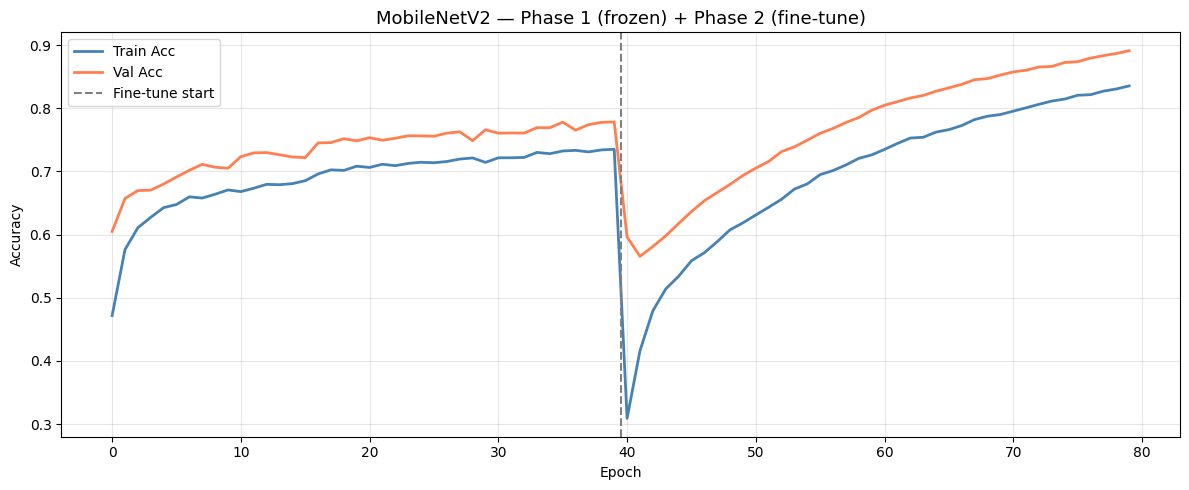

Best val accuracy: 0.8910 (89.10%)


In [6]:
acc_p1  = history_p1.history['accuracy']
acc_p2  = history_p2.history['accuracy']
vacc_p1 = history_p1.history['val_accuracy']
vacc_p2 = history_p2.history['val_accuracy']

all_acc  = acc_p1  + acc_p2
all_vacc = vacc_p1 + vacc_p2
split_ep = len(acc_p1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(all_acc,  label='Train Acc',  linewidth=2, color='steelblue')
ax.plot(all_vacc, label='Val Acc',    linewidth=2, color='coral')
ax.axvline(split_ep - 0.5, color='gray', linestyle='--', label='Fine-tune start')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('MobileNetV2 — Phase 1 (frozen) + Phase 2 (fine-tune)', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best = max(all_vacc)
print(f"Best val accuracy: {best:.4f} ({best*100:.2f}%)")

## 6. Save Final Model

In [7]:
mobilenet_model.save(MOBILENET_FINAL)
print(f"Final model saved → {MOBILENET_FINAL}")

Final model saved → /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/mobilenet_final.keras
